In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
import pandas as pd
from pathlib import Path


In [2]:
def leer_dosis_phits_tdeposit(filename):
    dosis = []
    leyendo_tabla = False

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            linea = line.strip()

            if linea.startswith("#  z-lower") and "proton" in linea:
                leyendo_tabla = True
                continue

            if leyendo_tabla:
                if linea.startswith("#") or linea.startswith("'") or linea.startswith("ms") or linea.startswith("wt") or linea.startswith("\\") or linea.startswith("e:"):
                    leyendo_tabla = False
                    continue

                partes = linea.split()

                if len(partes) == 4:
                    try:
                        z_lower = float(partes[0])
                        z_upper = float(partes[1])
                        dose = float(partes[2])
                        rerr = float(partes[3])

                        dosis.append(dose)

                    except ValueError:
                        pass

    return np.array(dosis)


In [3]:
carpeta_out = Path("../out")
file_path = carpeta_out / "histograma_dosis.out"

In [4]:
data_dosis = leer_dosis_phits_tdeposit(file_path)

print("Cantidad de valores leídos:", len(data_dosis))
print("Dosis mínima:", np.min(data_dosis))
print("Dosis máxima:", np.max(data_dosis))
print("Primeros valores:", data_dosis[:10])

Cantidad de valores leídos: 2112
Dosis mínima: 0.0
Dosis máxima: 0.40352
Primeros valores: [0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 5.3514e-06
 8.2921e-05 9.8988e-06 2.0071e-04 1.7773e-04]


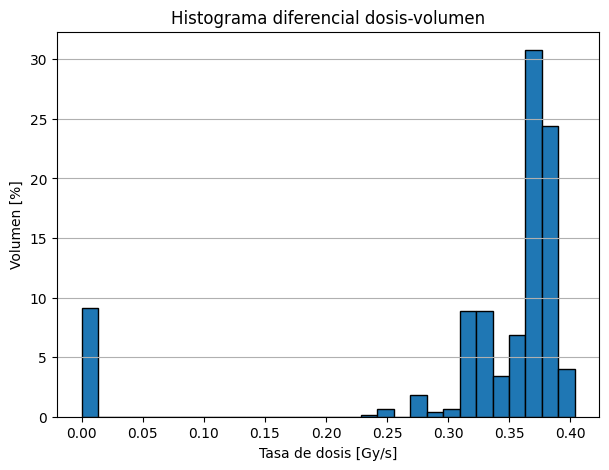

In [5]:
tiempo_seg = 1
data_dosis_fisica = data_dosis * tiempo_seg

n_bins = len(data_dosis_fisica)

if n_bins == 0:
    raise ValueError("No se leyó ningún dato de dosis. Revisá el formato del archivo.")

volumen_por_voxel = 100.0 / n_bins

bins_dosis = 30

volumen_por_intervalo, bordes_dosis = np.histogram(
    data_dosis_fisica,
    bins=bins_dosis,
    weights=np.ones_like(data_dosis_fisica) * volumen_por_voxel
)

centros_dosis = 0.5 * (bordes_dosis[:-1] + bordes_dosis[1:])
anchos = np.diff(bordes_dosis)

plt.figure(figsize=(7, 5))
plt.bar(
    centros_dosis,
    volumen_por_intervalo,
    width=anchos,
    align="center",
    edgecolor="black"
)

plt.xlabel("Tasa de dosis [Gy/s]")
plt.ylabel("Volumen [%]")
plt.title("Histograma diferencial dosis-volumen")
plt.grid(True, axis="y")
plt.show()

In [6]:
# MAXIMO DE DOSIS:
max_dosis = np.max(data_dosis_fisica)
print("Máximo de dosis:", max_dosis)
np.std(data_dosis_fisica)/np.mean(data_dosis_fisica)
print(f"Coeficiente de variación sin sacar nada: {100*np.std(data_dosis_fisica)/np.mean(data_dosis_fisica):.2f}%")

Máximo de dosis: 0.40352
Coeficiente de variación sin sacar nada: 32.71%


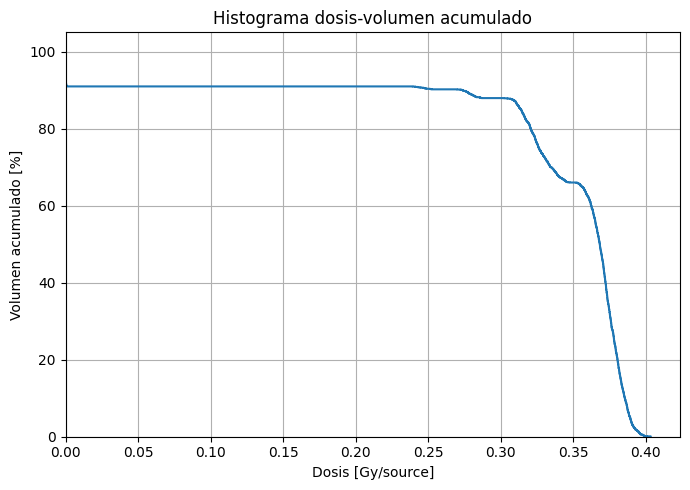

In [7]:
dosis = np.asarray(data_dosis_fisica)

dosis = dosis[np.isfinite(dosis)]

n_voxeles = len(dosis)

if n_voxeles == 0:
    raise ValueError("No hay datos de dosis.")

dosis_ordenada = np.sort(dosis)

dosis_unicas, indices = np.unique(
    dosis_ordenada,
    return_index=True
)

volumen_acumulado = 100.0 * (n_voxeles - indices) / n_voxeles

plt.figure(figsize=(7, 5))

plt.step(
    dosis_unicas,
    volumen_acumulado,
    where="post"
)

plt.xlabel("Dosis [Gy/source]")
plt.ylabel("Volumen acumulado [%]")
plt.title("Histograma dosis-volumen acumulado")

plt.xlim(left=0)
plt.ylim(0, 105)
plt.grid(True)
plt.tight_layout()

plt.show()

In [8]:
nx, ny, nz = 16, 33, 4

x_centros = np.linspace(-0.8, 0.8, nx, endpoint=False) + 0.8 / nx
y_centros = np.linspace(-1.65, 1.65, ny, endpoint=False) + 1.65 / ny
z_centros = np.linspace(98.38, 98.58, nz, endpoint=False) + 0.1 / nz

dosissinat = np.full((nx, ny, nz), np.nan)
err_relsinat = np.full((nx, ny, nz), np.nan)

ix_actual = None
iy_actual = None
contador_z = 0
leer_tabla = False

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:
        coincidencia = re.search(r"ix\s*=\s*(\d+).*iy\s*=\s*(\d+)", linea)

        if coincidencia:
            ix_actual = int(coincidencia.group(1)) - 1
            iy_actual = int(coincidencia.group(2)) - 1
            contador_z = 0
            leer_tabla = False
            continue

        if linea.strip().startswith("#  z-lower"):
            contador_z = 0
            leer_tabla = True
            continue

        if not leer_tabla:
            continue

        partes = linea.replace("D", "E").split()

        if len(partes) != 4:
            leer_tabla = False
            continue

        try:
            _, _, dosis, error = map(float, partes)
        except ValueError:
            leer_tabla = False
            continue

        if ix_actual is not None and iy_actual is not None and contador_z < nz:
            dosissinat[ix_actual, iy_actual, contador_z] = dosis
            err_relsinat[ix_actual, iy_actual, contador_z] = error
            contador_z += 1

print("Forma de la matriz:", dosissinat.shape)
print("Cantidad de valores leídos:", np.count_nonzero(~np.isnan(dosissinat)))

Forma de la matriz: (16, 33, 4)
Cantidad de valores leídos: 2112


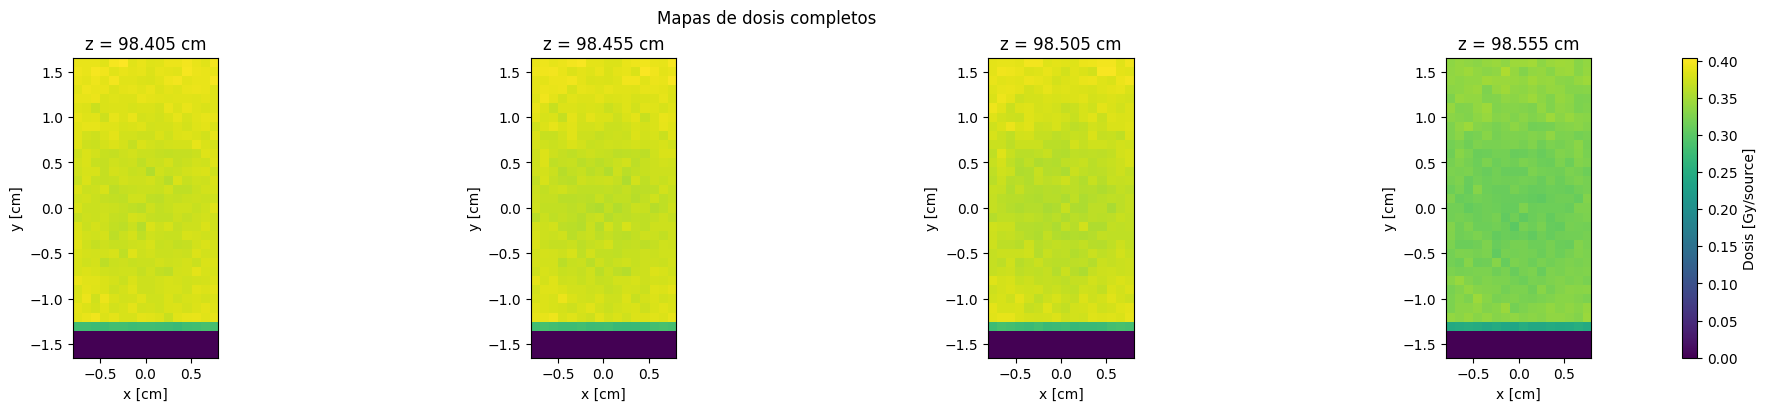

In [9]:
xmin, xmax = -0.8, 0.8
ymin, ymax = -1.65, 1.65

vmin = np.nanmin(dosissinat)
vmax = np.nanmax(dosissinat)

fig, axes = plt.subplots(
    1,
    nz,
    figsize=(5 * nz, 4),
    constrained_layout=True
)

axes = np.atleast_1d(axes)

for iz, ax in enumerate(axes):
    im = ax.imshow(
        dosissinat[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xlabel("x [cm]")
    ax.set_ylabel("y [cm]")
    ax.set_title(f"z = {z_centros[iz]:.3f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")
fig.suptitle("Mapas de dosis completos")
plt.show()

In [10]:
zmin_pouch, zmax_pouch = 98.38, 98.58

z_edges = np.linspace(zmin_pouch, zmax_pouch, nz + 1)
z_centros = (z_edges[:-1] + z_edges[1:]) / 2

X, Y, Z = np.meshgrid(
    x_centros,
    y_centros,
    z_centros,
    indexing="ij"
)

mascara_pouch = (
    (X / 0.8)**2
    + (Y / 1.65)**2
    + ((Z - np.mean([zmin_pouch, zmax_pouch])) / 1.0)**2
    <= 1
)

mascara_pouch &= (Z >= zmin_pouch) & (Z <= zmax_pouch)

dosis_sin_airesinat = np.where(mascara_pouch, dosissinat, np.nan)
err_sin_airesinat = np.where(mascara_pouch, err_relsinat, np.nan)

data_dosis2sinat = dosis_sin_airesinat[np.isfinite(dosis_sin_airesinat)]

print("Vóxeles dentro del pouch:", len(data_dosis2sinat))

Vóxeles dentro del pouch: 1648


In [11]:
validos = mascara_pouch & np.isfinite(dosissinat)

data_dosis2sinat = dosissinat[validos]
indices = np.argwhere(validos)

df_pouch = pd.DataFrame({
    "ix": indices[:, 0] + 1,
    "iy": indices[:, 1] + 1,
    "iz": indices[:, 2] + 1,
    "x": x_centros[indices[:, 0]],
    "y": y_centros[indices[:, 1]],
    "z": z_centros[indices[:, 2]],
    "dosis_Gy_source": dosissinat[validos],
    "err_rel": err_relsinat[validos]
})

print(f"Cantidad de vóxeles dentro del pouch: {len(data_dosis2sinat)}")
print(f"Dosis mínima: {np.min(data_dosis2sinat):.6f} Gy/source")
print(f"Dosis máxima: {np.max(data_dosis2sinat):.6f} Gy/source")
print(f"Dosis media: {np.mean(data_dosis2sinat):.6f} Gy/source")
print(f"Desviación estándar: {np.std(data_dosis2sinat):.6f} Gy/source")

df_pouch.head(4)

Cantidad de vóxeles dentro del pouch: 1648
Dosis mínima: 0.000000 Gy/source
Dosis máxima: 0.396920 Gy/source
Dosis media: 0.342648 Gy/source
Desviación estándar: 0.077884 Gy/source


,ix,iy,iz,x,y,z,dosis_Gy_source,err_rel
0,1,12,1,-0.75,-0.5,98.405,0.38118,0.0113
1,1,12,2,-0.75,-0.5,98.455,0.37640,0.0119
2,1,12,3,-0.75,-0.5,98.505,0.36819,0.0131
3,1,12,4,-0.75,-0.5,98.555,0.31989,0.0158


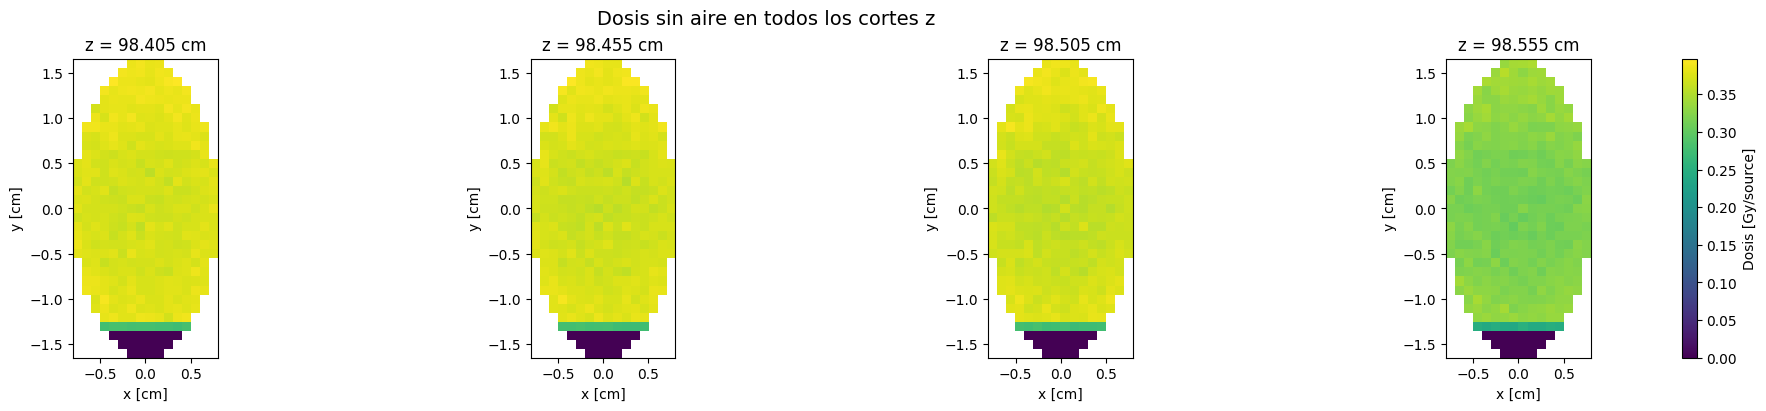

In [12]:
fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)

if nz == 1:
    axes = [axes]

vmin = np.nanmin(dosis_sin_airesinat)
vmax = np.nanmax(dosis_sin_airesinat)

for iz in range(nz):
    im = axes[iz].imshow(
        dosis_sin_airesinat[:, :, iz].T,
        origin="lower",
        extent=[xmin, xmax, ymin, ymax],
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    axes[iz].set_xlabel("x [cm]")
    axes[iz].set_ylabel("y [cm]")
    axes[iz].set_title(f"z = {z_centros[iz]:.3f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")

plt.suptitle("Dosis sin aire en todos los cortes z", fontsize=14)
plt.show()

In [13]:
mascara_pouch[:, :4, :] = False

dosis_en_pouch = np.where(mascara_pouch, dosissinat, np.nan)

print("Vóxeles finales:", np.sum(mascara_pouch))

Vóxeles finales: 1536


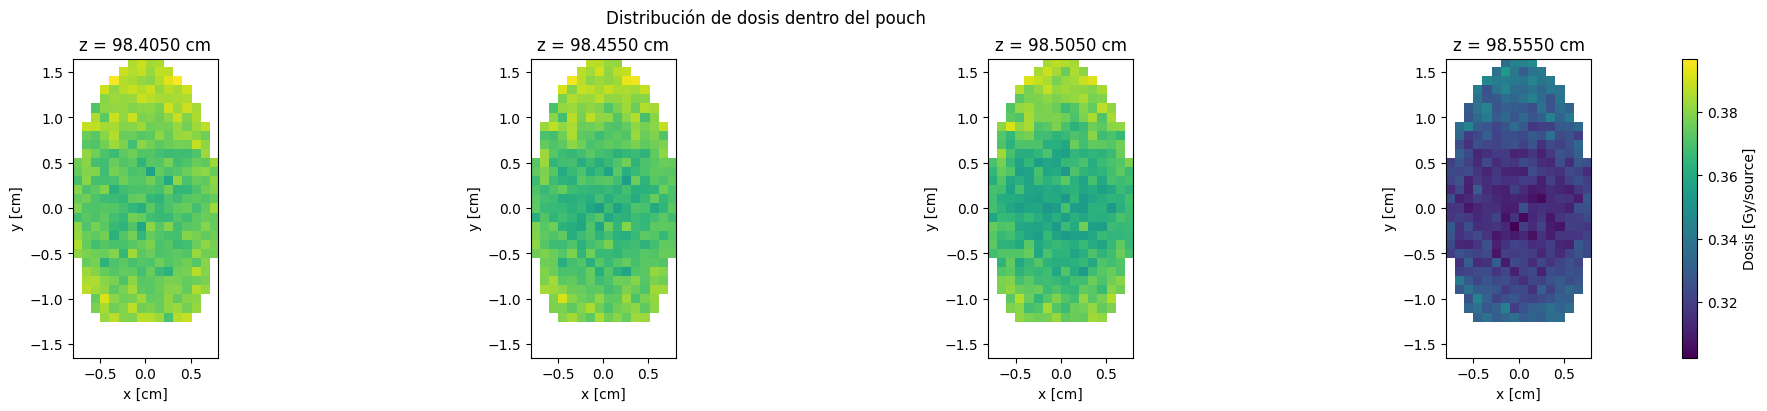

In [14]:
data_dosis_finalsinat = dosis_en_pouch[np.isfinite(dosis_en_pouch)]

vmin = np.min(data_dosis_finalsinat)
vmax = np.max(data_dosis_finalsinat)

cmap = plt.cm.viridis.copy()
cmap.set_bad("white")

fig, axes = plt.subplots(1, nz, figsize=(5 * nz, 4), constrained_layout=True)
axes = np.atleast_1d(axes)

for iz, ax in enumerate(axes):
    im = ax.imshow(
        dosis_en_pouch[:, :, iz].T,
        origin="lower",
        extent=[-0.8, 0.8, -1.65, 1.65],
        aspect="equal",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xlabel("x [cm]")
    ax.set_ylabel("y [cm]")
    ax.set_title(f"z = {z_centros[iz]:.4f} cm")

fig.colorbar(im, ax=axes, label="Dosis [Gy/source]")
fig.suptitle("Distribución de dosis dentro del pouch")
plt.show()

Número de vóxeles analizados: 1536


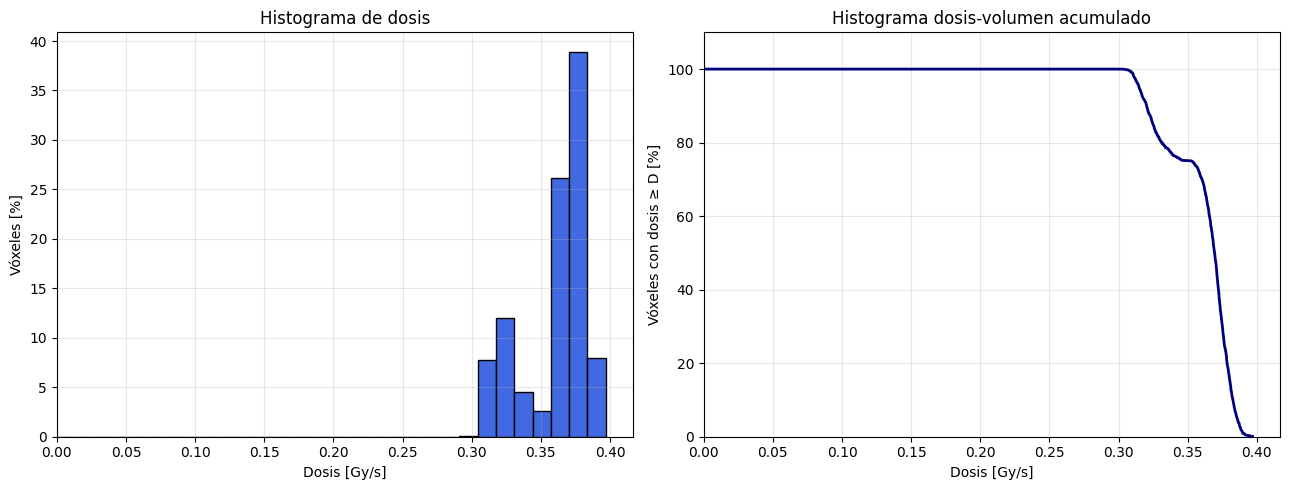

In [15]:
# ============================================================
# TOMAR SOLAMENTE LAS PRIMERAS 3 CAPAS EN Z
# ============================================================

dosis_4capas = dosis_en_pouch[:, :, :4]

data_dosis_4capas = dosis_4capas[
    np.isfinite(dosis_4capas)
]

print("Número de vóxeles analizados:", len(data_dosis_4capas))


# ============================================================
# ORDENAR DOSIS
# ============================================================

dosis_ordenada = np.sort(data_dosis_4capas)


# ============================================================
# VOLUMEN ACUMULADO
# ============================================================

volumen_acumulado = (
    100
    * np.arange(len(dosis_ordenada), 0, -1)
    / len(dosis_ordenada)
)


# ============================================================
# AGREGAR EL PUNTO INICIAL (0 Gy, 100 %)
# ============================================================

dosis_dvh = np.insert(dosis_ordenada, 0, 0)

volumen_dvh = np.insert(volumen_acumulado, 0, 100)


# ============================================================
# GRÁFICOS
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5)
)


# ============================================================
# HISTOGRAMA DE DOSIS
# ============================================================

dosis_max = np.max(data_dosis_4capas)

axes[0].hist(
    data_dosis_4capas,
    bins=30,
    range=(0, dosis_max),
    weights=np.ones(len(data_dosis_4capas))
            * 100 / len(data_dosis_4capas),
    color="royalblue",
    edgecolor="black"
)

axes[0].set_xlabel("Dosis [Gy/s]")
axes[0].set_ylabel("Vóxeles [%]")
axes[0].set_title("Histograma de dosis")

axes[0].set_xlim(left=0)

axes[0].grid(alpha=0.3)


# ============================================================
# DVH ACUMULADO
# ============================================================

axes[1].plot(
    dosis_dvh,
    volumen_dvh,
    color="navy",
    linewidth=2
)

axes[1].set_xlabel("Dosis [Gy/s]")
axes[1].set_ylabel("Vóxeles con dosis ≥ D [%]")
axes[1].set_title("Histograma dosis-volumen acumulado")

axes[1].set_xlim(left=0)
axes[1].set_ylim(0, 110)

axes[1].grid(alpha=0.3)


# ============================================================
# AJUSTE
# ============================================================

plt.tight_layout()
plt.show()

In [16]:
# MAXIMO DE DOSIS:
max_dosis = np.max( data_dosis_4capas)
print("Máximo de dosis:", max_dosis)
np.std( data_dosis_4capas)/np.mean( data_dosis_4capas)
print(f"Coeficiente de variación sacando vóxeles de baja dosis: {100*np.std( data_dosis_4capas)/np.mean( data_dosis_4capas):.2f}%")

Máximo de dosis: 0.39692
Coeficiente de variación sacando vóxeles de baja dosis: 6.42%
